# CASE 01 KPI & Segmentation

## tl;dr

이 노트북은 통계 단계에서 확인한 집중도와 시기 패턴을 전제로, 의사결정자가 반복해서 볼 KPI와 RFM 세그먼트를 확정합니다. 세그먼트는 유지·육성·재활성화·관찰·저우선 행동으로만 연결하며, 이익이나 캠페인 인과효과는 계산하지 않습니다.

In [1]:
from pathlib import Path
import hashlib
import sys

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

pd.set_option("display.max_columns", None)
pd.set_option("display.float_format", lambda value: f"{value:,.2f}")

CASE_NAME = "01_retail_customer_analytics"
case_dir_candidates = [
    Path.cwd(),
    Path.cwd().parent,
    Path.cwd() / "cases" / CASE_NAME,
]
case_dir = next(
    (path.resolve() for path in case_dir_candidates
     if (path / "data" / "raw" / "online_retail_II.xlsx").exists()),
    None,
)
if case_dir is None:
    raise FileNotFoundError(
        "online_retail_II.xlsx를 찾지 못했습니다. 저장소 루트 또는 notebooks 폴더에서 실행하세요."
    )

sys.path.insert(0, str(case_dir / "src"))
from data_preparation import load_and_prepare_retail_data
from kpi_segmentation import run_kpi_segmentation

raw_path = case_dir / "data" / "raw" / "online_retail_II.xlsx"
figure_dir = case_dir / "evidence" / "kpi_figures"
figure_dir.mkdir(parents=True, exist_ok=True)
prepared = load_and_prepare_retail_data(raw_path)
kpis = run_kpi_segmentation(prepared)
source_sha256 = hashlib.sha256(raw_path.read_bytes()).hexdigest().upper()
value_lookup = kpis.values.set_index("kpi")["value"]

display(Markdown(f'''
**실행 요약**

- RFM 기준일: **{kpis.snapshot_date:%Y-%m-%d}** (마지막 거래일 + 1일)
- 정상 매출: **£{value_lookup["Gross sales"]:,.0f}**, AOV: **£{value_lookup["AOV"]:,.0f}**
- 식별 고객: **{int(value_lookup["Identified customers"]):,}명**, 재구매율: **{value_lookup["Repeat-customer rate"]:.1%}**
- 세그먼트는 최근성·빈도·금액 오분위 점수이며 고객 성격의 증명이 아닙니다.
'''))


**실행 요약**

- RFM 기준일: **2011-12-10** (마지막 거래일 + 1일)
- 정상 매출: **£20,972,595**, AOV: **£513**
- 식별 고객: **5,878명**, 재구매율: **72.8%**
- 세그먼트는 최근성·빈도·금액 오분위 점수이며 고객 성격의 증명이 아닙니다.


## Context & Methods

### KPI 계약

각 지표는 분모, 분석 단위, 기간, 포함·제외 조건을 사전 정의합니다. 통계 단계의 민감도에서 중복 제거가 핵심 비중 지표를 뒤집지 않았다는 전제를 사용합니다.

### RFM 규칙

- Recency: 기준일 − 마지막 정상 구매일, 낮을수록 점수 5
- Frequency: `Invoice_Key` 고유 수, 높을수록 점수 5
- Monetary: 정상 매출 합계, 높을수록 점수 5
- 동점은 `rank(method='first')` 후 오분위로 끊어 빈 구간을 피합니다.
- 세그먼트 이름은 CRM 우선순위 라벨이며 군집분석 결과가 아닙니다.

## Data

### 1. Reconciliation

In [2]:
assert source_sha256 == "BCBE73B35F5B7BABF197FB0CB983A11F5D9FF929078D4AA53D171B1F2DF2E980"
assert len(kpis.rfm) == int(value_lookup["Identified customers"])
assert kpis.rfm["segment"].notna().all()
print("PASS: KPI inputs match the CASE 01 data contract.")
display(kpis.dictionary)

PASS: KPI inputs match the CASE 01 data contract.


,kpi,formula,grain,period,include,exclude
0,Gross sales,SUM(Quantity × Price),sales line (sales_analysis_df),2009-12-01 to 2011-12-09,"Quantity > 0, Price > 0, not cancelled/returned","C-invoices, negative quantity, zero/negative p..."
1,Observed net transaction value,SUM(Quantity × Price) over raw rows,raw line (retail_df),2009-12-01 to 2011-12-09,All raw rows,None; not accounting revenue
2,AOV,Gross sales / COUNT DISTINCT Invoice_Key,completed order,same as gross sales,sales_analysis_df orders,Line-item averages
3,Identified-customer revenue share,Customer-analysis revenue / Gross sales,sales line,same as gross sales,Normal positive sales with Customer ID,Guest checkout lines from the numerator
4,Repeat-customer rate,Customers with ≥2 Invoice_Key / identified cus...,identified customer,observation window only,customer_analysis_df,Pre/post-window purchases; missing Customer ID
5,UK revenue share,UK gross sales / Gross sales,sales line country field,same as gross sales,Country = United Kingdom,Country is not nationality
6,Negative-value-to-gross ratio,ABS(SUM of negative Quantity × Price) / Gross ...,raw line,same as gross sales,Negative transaction amounts,Not a matched refund rate


## Results

### 2. Confirmed KPI values

In [3]:
display(kpis.values)

,kpi,value,unit
0,Gross sales,"20,972,594.57",GBP
1,Observed net transaction value,"19,287,250.57",GBP
2,Completed orders,"40,911.00",orders
3,AOV,512.64,GBP / order
4,Identified customers,"5,878.00",customers
5,Identified-customer revenue share,0.85,share
6,Repeat-customer rate,0.73,share
7,UK revenue share,0.85,share
8,Negative-value-to-gross ratio,0.08,ratio
9,Peak complete-month gross sales,"1,509,496.33",GBP (2011-11)


### 3. RFM segments

In [4]:
display(kpis.segment_summary.style.format({
    "customers": "{:,.0f}",
    "orders": "{:,.0f}",
    "revenue": "£{:,.0f}",
    "median_recency": "{:.0f}",
    "median_frequency": "{:.1f}",
    "median_monetary": "£{:,.0f}",
    "customer_share": "{:.1%}",
    "revenue_share": "{:.1%}",
}))

,segment,action,customers,orders,revenue,median_recency,median_frequency,median_monetary,customer_share,revenue_share
2,Champions,유지,"1,290","22,611","£12,083,792",16,11.0,"£4,049",21.9%,68.1%
5,Loyal,유지,703,"5,563","£1,915,519",78,6.0,"£1,734",12.0%,10.8%
8,Potential,육성,232,748,"£554,477",60,3.0,"£1,689",3.9%,3.1%
7,New / Recent,육성,446,654,"£394,959",26,1.0,£373,7.6%,2.2%
1,Cannot Lose,재활성화,229,"2,126","£1,021,613",333,7.0,"£2,282",3.9%,5.8%
0,At Risk,재활성화,599,"2,099","£616,182",377,3.0,£801,10.2%,3.5%
4,Hibernating High Value,재활성화,65,106,"£183,879",423,2.0,"£1,858",1.1%,1.0%
6,Need Attention,관찰,856,"2,016","£491,566",72,2.0,£542,14.6%,2.8%
3,Hibernating,저우선,"1,458","1,822","£481,442",436,1.0,£265,24.8%,2.7%


C:\Users\PC\AppData\Local\Temp\ipykernel_72636\3557467395.py:12: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\PC\AppData\Local\Temp\ipykernel_72636\3557467395.py:12: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\PC\AppData\Local\Temp\ipykernel_72636\3557467395.py:12: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\PC\AppData\Local\Temp\ipykernel_72636\3557467395.py:12: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\PC\AppData\Local\Temp\ipykernel_72636\3557467395.py:12: UserWarning: Glyph 47676 (\N{HANGUL SYLLABLE MEON}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\PC\AppData\Local\Temp\ipykernel_72636\3557467395.py:12: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\P

D:\golden-data-lab\golden-data-lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 47588 (\N{HANGUL SYLLABLE MAE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\golden-data-lab\golden-data-lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 52636 (\N{HANGUL SYLLABLE CUL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\golden-data-lab\golden-data-lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 49464 (\N{HANGUL SYLLABLE SE}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\golden-data-lab\golden-data-lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 44536 (\N{HANGUL SYLLABLE GEU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\golden-data-lab\golden-data-lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 47676 (\N{HANGUL SYLLABLE MEON}) missing fr

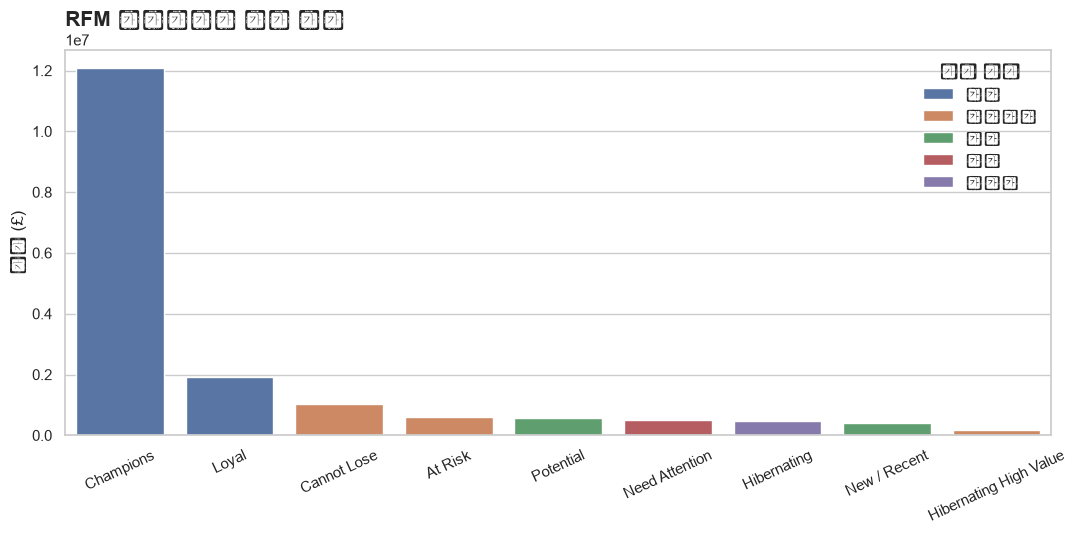

In [5]:
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False
sns.set_theme(style="whitegrid")
plot_frame = kpis.segment_summary.sort_values("revenue", ascending=False)
fig, ax = plt.subplots(figsize=(11, 5.5))
sns.barplot(data=plot_frame, x="segment", y="revenue", hue="action", dodge=False, ax=ax)
ax.set_title("RFM 세그먼트별 정상 매출", loc="left", fontsize=15, weight="bold")
ax.set_xlabel("")
ax.set_ylabel("매출 (£)")
ax.tick_params(axis="x", labelrotation=25)
ax.legend(title="실행 유형", frameon=False)
fig.tight_layout()
fig.savefig(figure_dir / "01_rfm_segment_revenue.png", dpi=160, bbox_inches="tight")
plt.show()

### 4. Cohort retention

period_number,0,1,2,3,4,5,6
cohort_month,,,,,,,
2010-01-01,1.00,0.21,0.31,0.30,0.26,0.30,0.26
2010-02-01,1.00,0.24,0.23,0.29,0.25,0.20,0.19
2010-03-01,1.00,0.19,0.23,0.24,0.23,0.20,0.25
2010-04-01,1.00,0.19,0.19,0.16,0.18,0.22,0.28
2010-05-01,1.00,0.16,0.17,0.17,0.18,0.26,0.21
2010-06-01,1.00,0.17,0.19,0.20,0.23,0.28,0.13
2010-07-01,1.00,0.16,0.18,0.30,0.29,0.14,0.11
2010-08-01,1.00,0.20,0.30,0.32,0.17,0.12,0.10


C:\Users\PC\AppData\Local\Temp\ipykernel_72636\2162165927.py:12: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\PC\AppData\Local\Temp\ipykernel_72636\2162165927.py:12: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\PC\AppData\Local\Temp\ipykernel_72636\2162165927.py:12: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\PC\AppData\Local\Temp\ipykernel_72636\2162165927.py:12: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\PC\AppData\Local\Temp\ipykernel_72636\2162165927.py:12: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\PC\AppData\Local\Temp\ipykernel_72636\2162165927.py:12: UserWarning: Glyph 52395 (\N{HANGUL SYLLABLE CEOS}) missing from font(s) Arial.
  fig.tight_layout()
C:\Users\PC

D:\golden-data-lab\golden-data-lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 53076 (\N{HANGUL SYLLABLE KO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\golden-data-lab\golden-data-lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 54840 (\N{HANGUL SYLLABLE HO}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\golden-data-lab\golden-data-lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 53944 (\N{HANGUL SYLLABLE TEU}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\golden-data-lab\golden-data-lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 50900 (\N{HANGUL SYLLABLE WEOL}) missing from font(s) Arial.
  fig.canvas.print_figure(bytes_io, **kw)
D:\golden-data-lab\golden-data-lab\.venv\Lib\site-packages\IPython\core\pylabtools.py:158: UserWarning: Glyph 52264 (\N{HANGUL SYLLABLE CA}) missing from

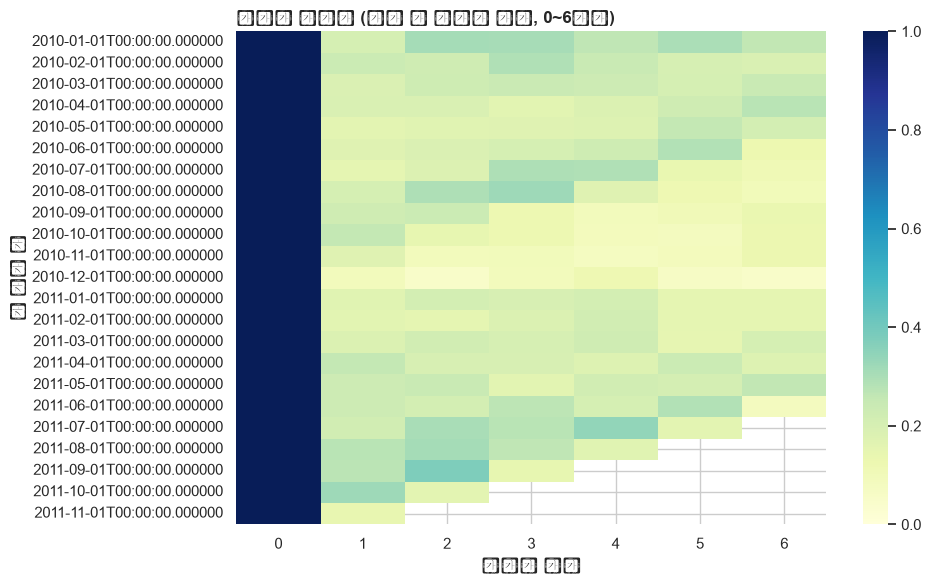

In [6]:
retention = kpis.cohort_retention
heatmap = (
    retention.loc[~retention["is_partial_cohort"] & retention["period_number"].between(0, 6)]
    .pivot(index="cohort_month", columns="period_number", values="retention")
)
display(heatmap.round(3).head(8))
fig, ax = plt.subplots(figsize=(10, 6))
sns.heatmap(heatmap, cmap="YlGnBu", vmin=0, vmax=1, ax=ax)
ax.set_title("코호트 유지율 (부분 월 코호트 제외, 0~6개월)", loc="left", weight="bold")
ax.set_xlabel("코호트 월차")
ax.set_ylabel("첫 구매 월")
fig.tight_layout()
fig.savefig(figure_dir / "02_cohort_retention.png", dpi=160, bbox_inches="tight")
plt.show()

### 5. CRM priority

In [7]:
display(kpis.priority.style.format({
    "customers": "{:,.0f}",
    "revenue": "£{:,.0f}",
    "customer_share": "{:.1%}",
    "revenue_share": "{:.1%}",
    "median_recency": "{:.0f}",
}))
print("유지 세그먼트는 현재 기여, 재활성화 세그먼트는 최근성이 떨어진 과거 고가치 고객입니다.")

,segment,action,customers,revenue,customer_share,revenue_share,median_recency,priority_note
2,Champions,유지,"1,290","£12,083,792",21.9%,68.1%,16,현재 매출 기여가 큰 활성 고객. 서비스 유지 우선.
5,Loyal,유지,703,"£1,915,519",12.0%,10.8%,78,현재 매출 기여가 큰 활성 고객. 서비스 유지 우선.
1,Cannot Lose,재활성화,229,"£1,021,613",3.9%,5.8%,333,과거 가치가 있으나 최근성이 낮음. 재활성화 후보.
0,At Risk,재활성화,599,"£616,182",10.2%,3.5%,377,과거 가치가 있으나 최근성이 낮음. 재활성화 후보.
4,Hibernating High Value,재활성화,65,"£183,879",1.1%,1.0%,423,과거 가치가 있으나 최근성이 낮음. 재활성화 후보.


유지 세그먼트는 현재 기여, 재활성화 세그먼트는 최근성이 떨어진 과거 고가치 고객입니다.


### Interpretation boundary

- RFM 점수는 관측 기간의 완료 매출만 사용합니다. 원가, 마진, 광고비가 없어 CLV가 아닙니다.
- 재구매와 유지는 창 안의 송장만 세므로 창 밖 활동은 알 수 없습니다.
- 세그먼트 크기가 달라도 같은 마케팅 처방을 가정하지 않습니다.
- 다음 단계는 이 표를 한 페이지 의사결정 화면으로 옮기는 것입니다.